<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing an Autoencoder for Image Denoising: Enhancing Image Quality by Removing Noise from Noisy Inputs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

In [5]:
(x_train, _), (x_test, _) = mnist.load_data()

In [6]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [8]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [9]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [10]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
x_train_noisy = np.reshape(x_train_noisy, (len(x_train_noisy), 28, 28, 1))
x_test_noisy = np.reshape(x_test_noisy, (len(x_test_noisy), 28, 28, 1))

In [11]:
input_img = Input(shape=(28, 28, 1))

In [12]:
# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

In [13]:
# Decoder
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

In [14]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

In [15]:
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 246ms/step - loss: 0.2901 - val_loss: 0.1273
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 149s 261ms/step - loss: 0.1233 - val_loss: 0.1146
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 259ms/step - loss: 0.1147 - val_loss: 0.1107
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 258ms/step - loss: 0.1109 - val_loss: 0.1074
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 268ms/step - loss: 0.1079 - val_loss: 0.1055
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.1064 - val_loss: 0.1044
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 258ms/step - loss: 0.1050 - val_loss: 0.1033
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 254ms/step - loss: 0.1041 - val_loss: 0.1027
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 256ms/step - loss: 0.1035 - val_loss: 0.1023
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 260ms/step - loss: 0.1027 - val_loss: 0.1024


In [16]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


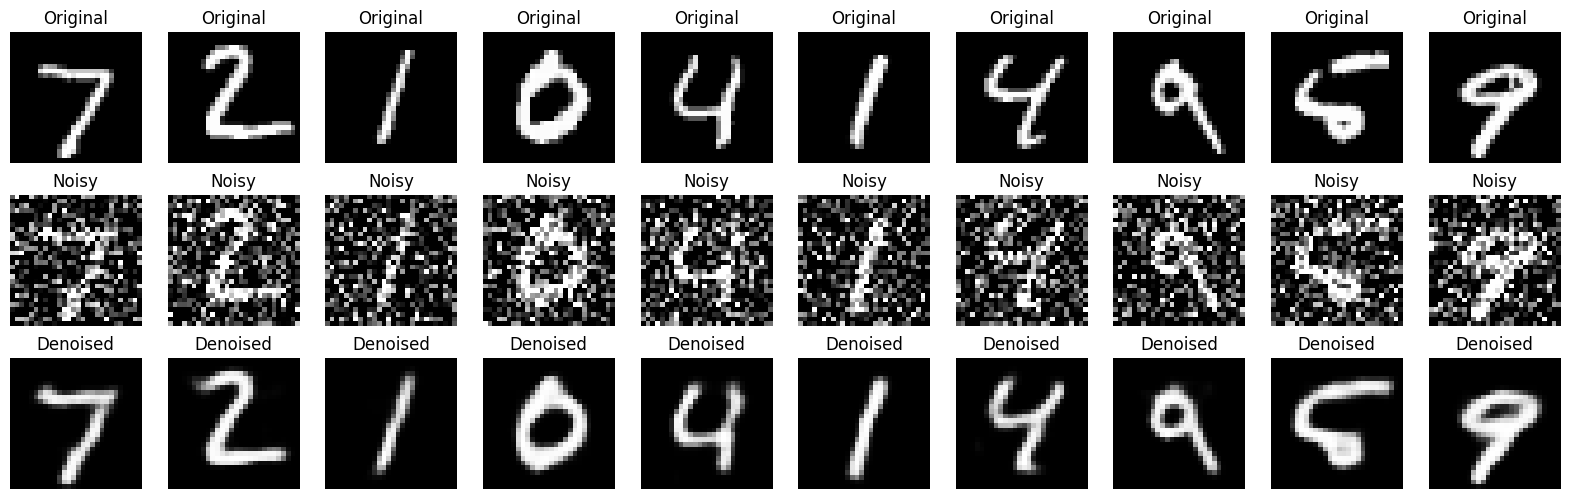

In [24]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 2 * n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()


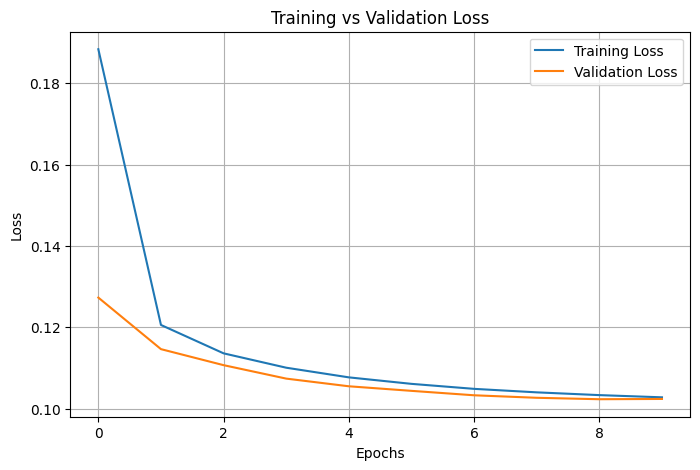

In [23]:
# Plot training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(autoencoder.history.history['loss'], label='Training Loss')
plt.plot(autoencoder.history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
